In [6]:
!pip install pm4py

In [5]:
import pm4py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Import Log

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
log = pm4py.read_xes('/content/drive/MyDrive/dataset/BPI Challenge 2017.xes')

# Verify
print(f"Successfully loaded {len(log)} traces.")

/usr/local/lib/python3.12/dist-packages/pm4py/utils.py:1027: UserWarning: Install the optional requirement `r4pm` to import/export files faster. `rustxes` remains supported as a fallback.
  warnings.warn(


parsing log, completed traces ::   0%|          | 0/31509 [00:00<?, ?it/s]

Successfully loaded 1202267 traces.


# Filter Log A

In [25]:
log_a_filtered = pm4py.filter_event_attribute_values(
    log,
    "concept:name",
    ["A_Pending", "A_Cancelled", "A_Denied"],
    level="event",
    retain=True
)

# Filter traces to only those ending in the desired outcome activities
admitted_end_activities = ["A_Pending", "A_Cancelled", "A_Denied"]
log_a = pm4py.filter_end_activities(
    log_A_filtered,
    admitted_end_activities
)

print(f"Filtered log contains {len(log_A)} traces.")

Filtered log contains 31412 traces.


# Filter Log A and O

In [52]:
log_ao = log[log['concept:name'].str.startswith(('A_', 'O_'))].copy()

# Verify
remaining_activities = log_ao['concept:name'].unique()
print(f"Remaining activities: {remaining_activities}")
print(f"Number of events after filtering W_: {len(log_ao)}")

Remaining activities: ['A_Create Application' 'A_Submitted' 'A_Concept' 'A_Accepted'
 'O_Create Offer' 'O_Created' 'O_Sent (mail and online)' 'A_Complete'
 'A_Validating' 'O_Returned' 'A_Incomplete' 'O_Accepted' 'A_Pending'
 'A_Denied' 'O_Refused' 'O_Cancelled' 'A_Cancelled' 'O_Sent (online only)']
Number of events after filtering W_: 433444


# Distribution of End Activities

Distribution of end activities for event log

In [21]:
end_activities = pm4py.get_end_activities(log)
end_activities

{'W_Validate application': 12662,
 'O_Cancelled': 4436,
 'W_Call after offers': 9457,
 'W_Call incomplete files': 4676,
 'W_Complete application': 144,
 'W_Assess potential fraud': 102,
 'W_Personal Loan collection': 2,
 'W_Shortened completion ': 5,
 'A_Denied': 1,
 'O_Sent (online only)': 8,
 'O_Sent (mail and online)': 15,
 'O_Returned': 1}

In [27]:
end_activities_a = pm4py.get_end_activities(log_a)
end_activities_a

{'A_Pending': 17228, 'A_Denied': 3752, 'A_Cancelled': 10431}

In [55]:
end_activities_ao = pm4py.get_end_activities(log_ao)
end_activities_ao

{'A_Pending': 12792,
 'O_Refused': 3719,
 'O_Cancelled': 14708,
 'A_Cancelled': 161,
 'A_Denied': 33,
 'A_Incomplete': 29,
 'A_Validating': 3,
 'O_Sent (online only)': 12,
 'O_Sent (mail and online)': 20,
 'A_Complete': 30,
 'O_Returned': 2}

#### Visualisation Distribution

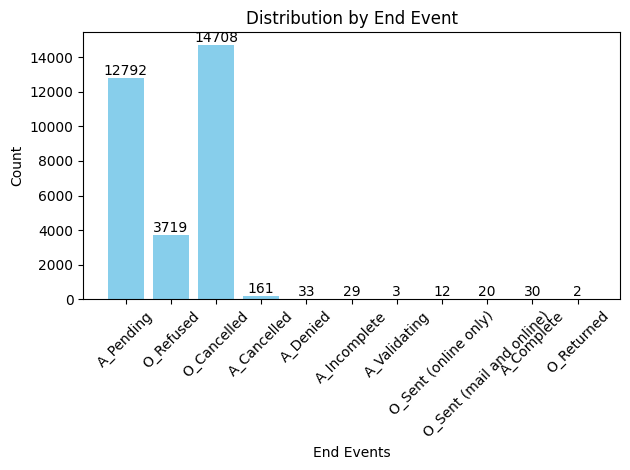

In [58]:
activities = list(end_activities.keys())
counts = [end_activities[activity] for activity in activities]

bars = plt.bar(activities, counts, color='skyblue')

plt.xlabel('End Events')
plt.ylabel('Count')
plt.title('Distribution by End Event')
plt.xticks(rotation=45)
plt.tight_layout()

for i, count in enumerate(counts):
    plt.text(i, count, str(count), ha='center', va='bottom')

plt.show()


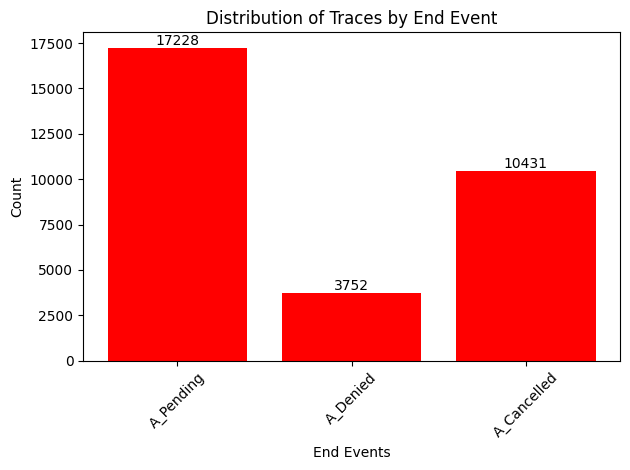

In [74]:
activities = list(end_activities_a.keys())
counts = [end_activities_a[activity] for activity in activities]

bars = plt.bar(activities, counts, color='red')

plt.xlabel('End Events')
plt.ylabel('Count')
plt.title('Distribution of Traces by End Event')
plt.xticks(rotation=45)
plt.tight_layout()

# Add values on the bars
for i, count in enumerate(counts):
    plt.text(i, count, str(count), ha='center', va='bottom')

plt.show()

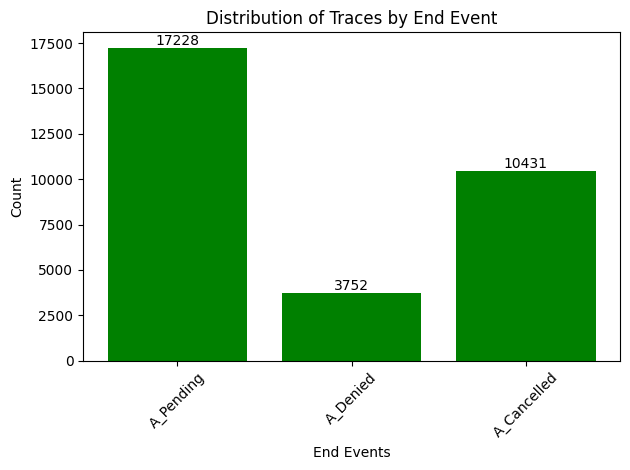

In [75]:
activities = list(end_activities_ao.keys())
counts = [end_activities_ao[activity] for activity in activities]

bars = plt.bar(activities, counts, color='green')

plt.xlabel('End Events')
plt.ylabel('Count')
plt.title('Distribution of Traces by End Event')
plt.xticks(rotation=45)
plt.tight_layout()

# Add values on the bars
for i, count in enumerate(counts):
    plt.text(i, count, str(count), ha='center', va='bottom')

plt.show()

#### Visualisation Successful and Unsuccessful Distribution

categorized as either successful or unsuccessful applications (A_Pending) is successful, whereas (A_Denied) and (A_Cancelled) is unsuccessful.

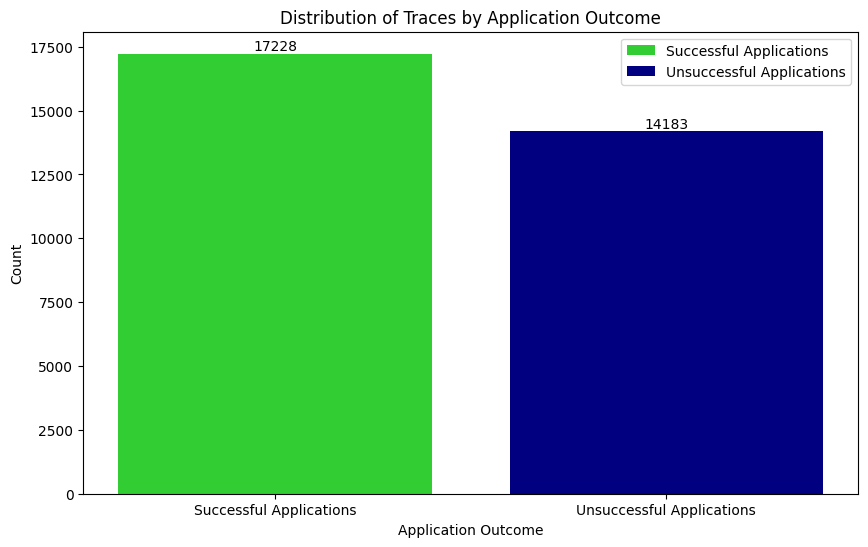

In [77]:
successful_counts = [end_activities_a.get('A_Pending', 0)]
unsuccessful_counts = [count for activity, count in end_activities_a.items() if activity != 'A_Pending']

fig, ax = plt.subplots(figsize=(10, 6))



ax.bar('Successful Applications', successful_counts, color='limegreen', label='Successful Applications')
ax.bar('Unsuccessful Applications', sum(unsuccessful_counts), color='navy', label='Unsuccessful Applications')

for bar, count in zip(ax.patches, [successful_counts[0], sum(unsuccessful_counts)]):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height, count, ha='center', va='bottom')

ax.set_xlabel('Application Outcome')
ax.set_ylabel('Count')
ax.set_title('Distribution of Traces by Application Outcome')
ax.legend()

plt.show()

# analyzing the flow

In [78]:
pm4py.get_start_activities(log_ao)

{'A_Create Application': 31509}

In [79]:
len(pm4py.get_variants_as_tuples(log_ao))

2630

Transform the log into a dataframe

In [80]:
df = pm4py.convert_to_dataframe(log_ao)
df.head(5)

,Action,org:resource,concept:name,EventOrigin,EventID,lifecycle:transition,time:timestamp,case:LoanGoal,case:ApplicationType,case:concept:name,case:RequestedAmount,FirstWithdrawalAmount,NumberOfTerms,Accepted,MonthlyCost,Selected,CreditScore,OfferedAmount,OfferID,start_timestamp
0,Created,User_1,A_Create Application,Application,Application_652823628,complete,2016-01-01 09:51:15.304000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016-01-01 09:51:15.304000+00:00
1,statechange,User_1,A_Submitted,Application,ApplState_1582051990,complete,2016-01-01 09:51:15.352000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016-01-01 09:51:15.352000+00:00
5,statechange,User_1,A_Concept,Application,ApplState_642383566,complete,2016-01-01 09:52:36.413000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016-01-01 09:52:36.413000+00:00
8,statechange,User_52,A_Accepted,Application,ApplState_99568828,complete,2016-01-02 11:23:04.299000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016-01-02 11:23:04.299000+00:00
9,Created,User_52,O_Create Offer,Offer,Offer_148581083,complete,2016-01-02 11:29:03.994000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,20000.0,44.0,True,498.29,True,979.0,20000.0,NaN,2016-01-02 11:29:03.994000+00:00


# Process Model Visualization

#### Visualisation DFG

##### Full Log A_, O_, W_

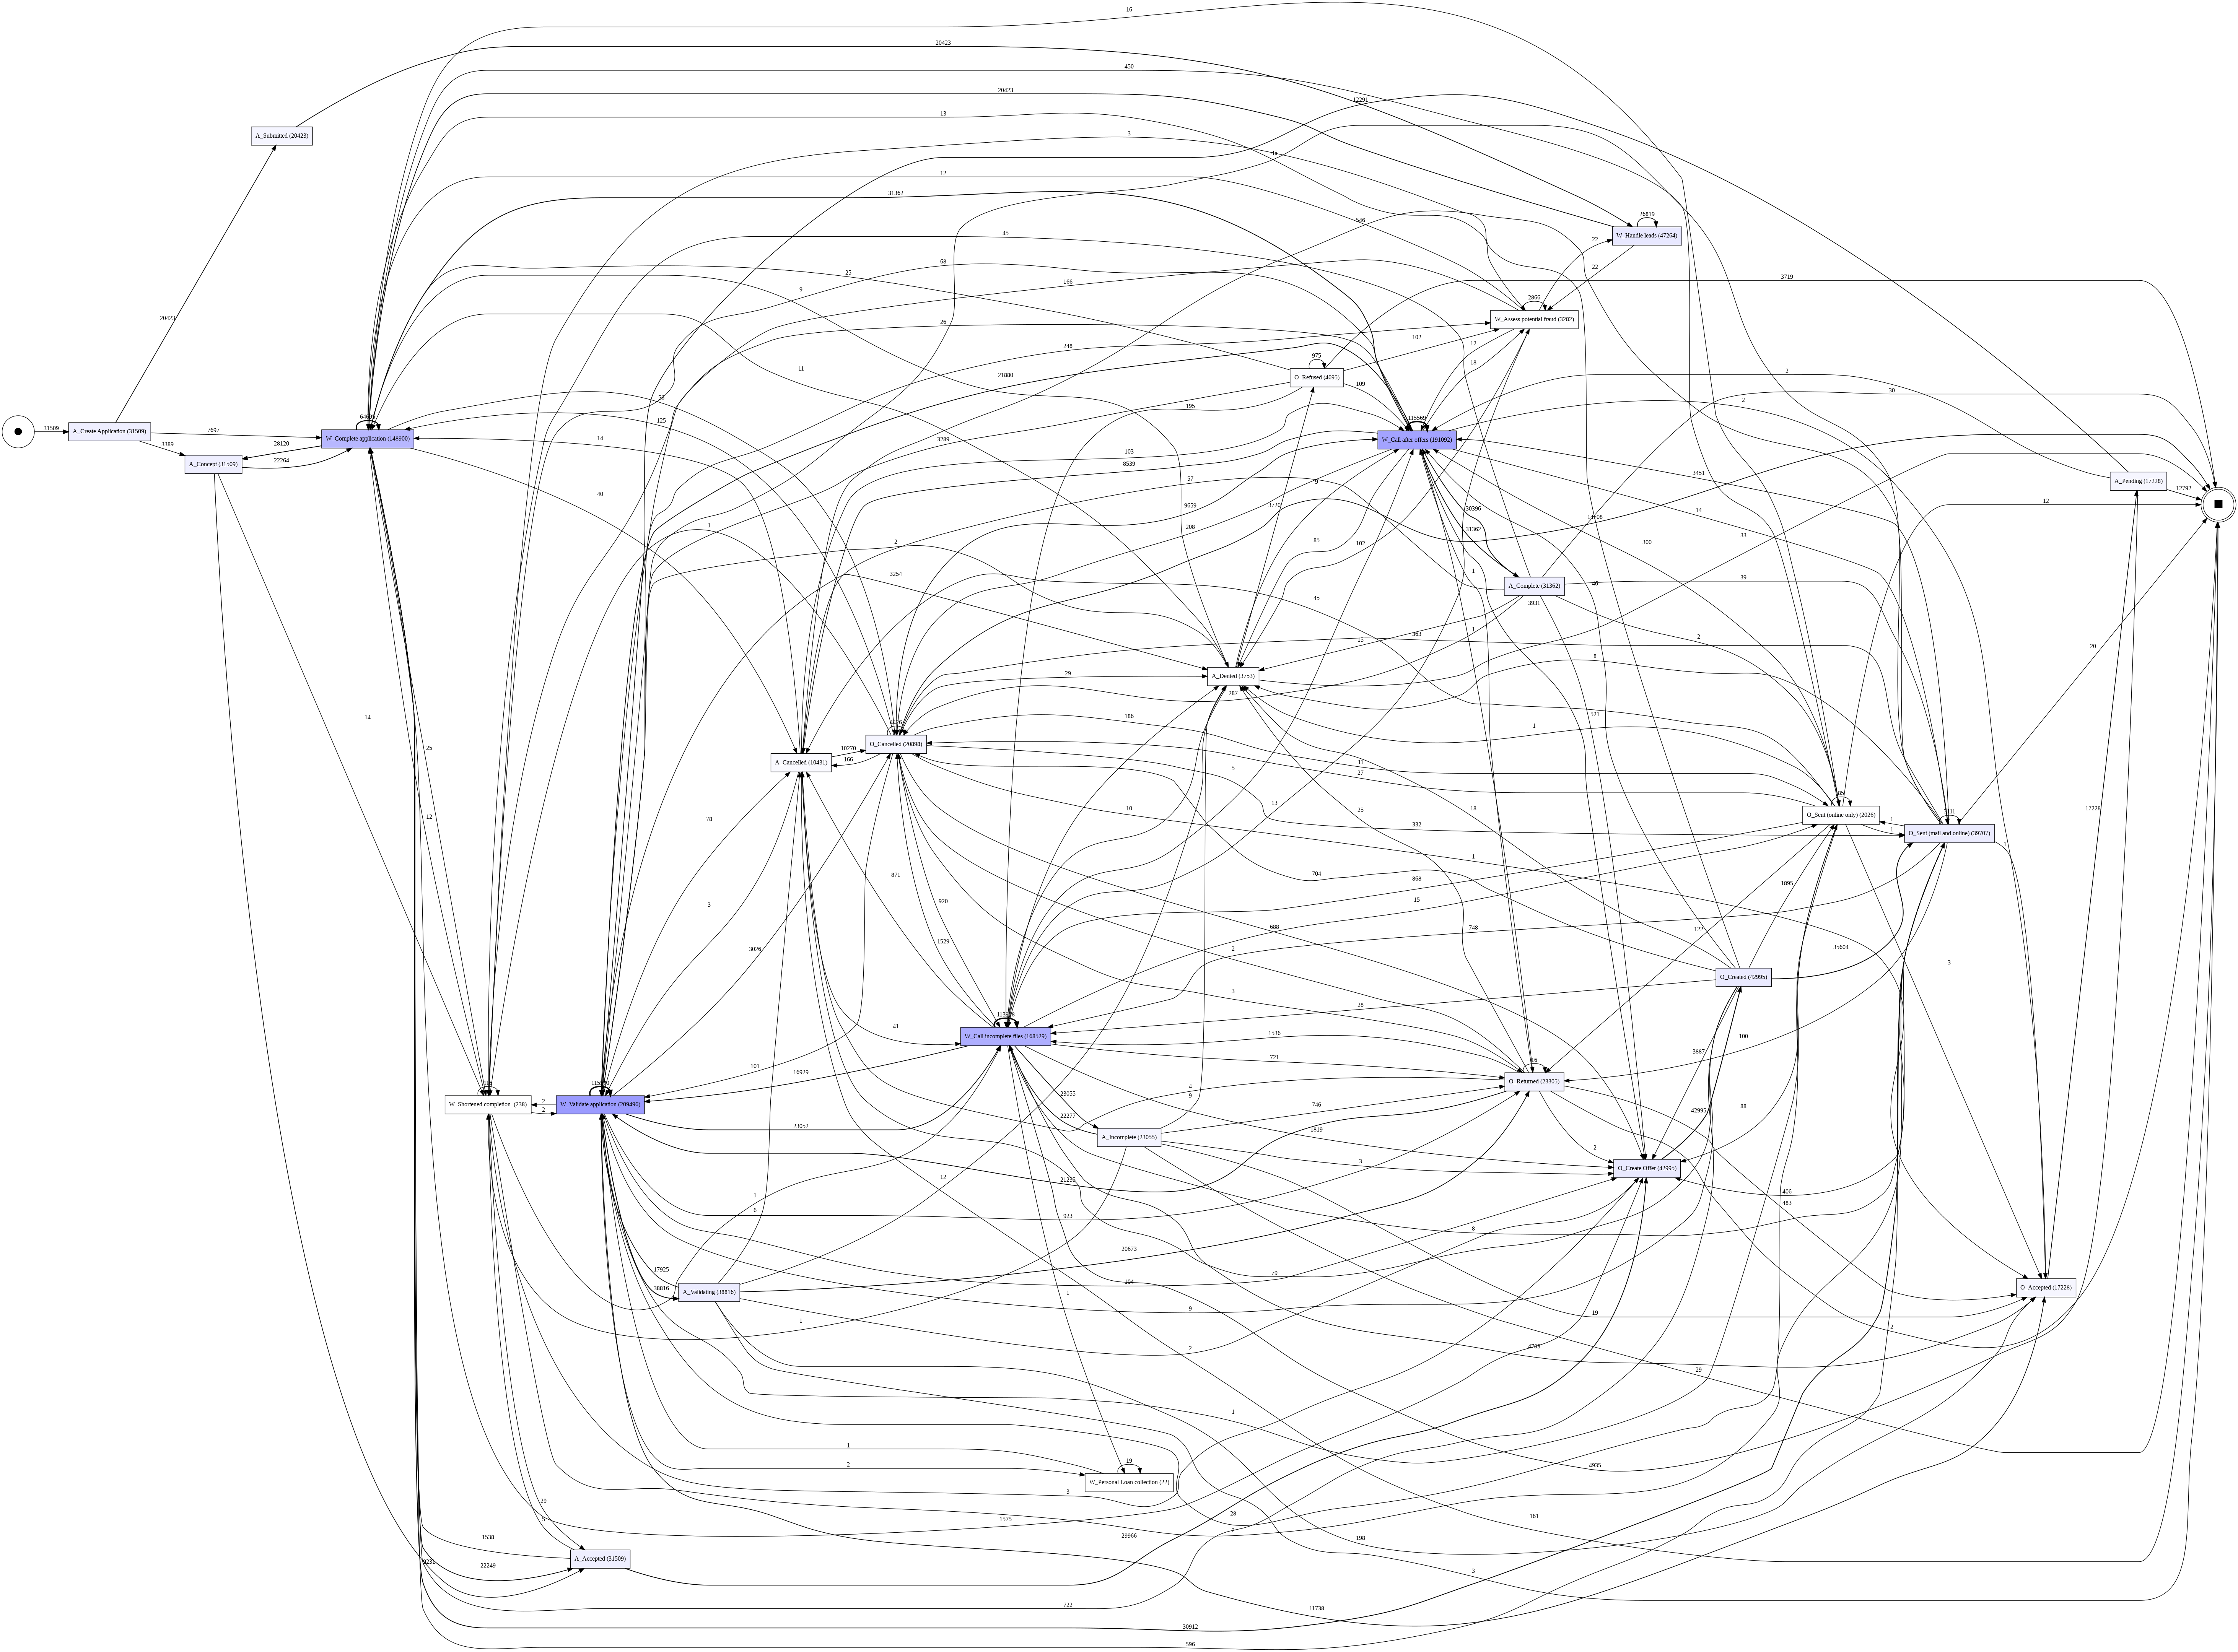

In [81]:
dfg, start_activities, end_activities_ao = pm4py.discover_dfg(log)
pm4py.view_dfg(dfg, start_activities, end_activities)

##### Filtered Log A_ and O

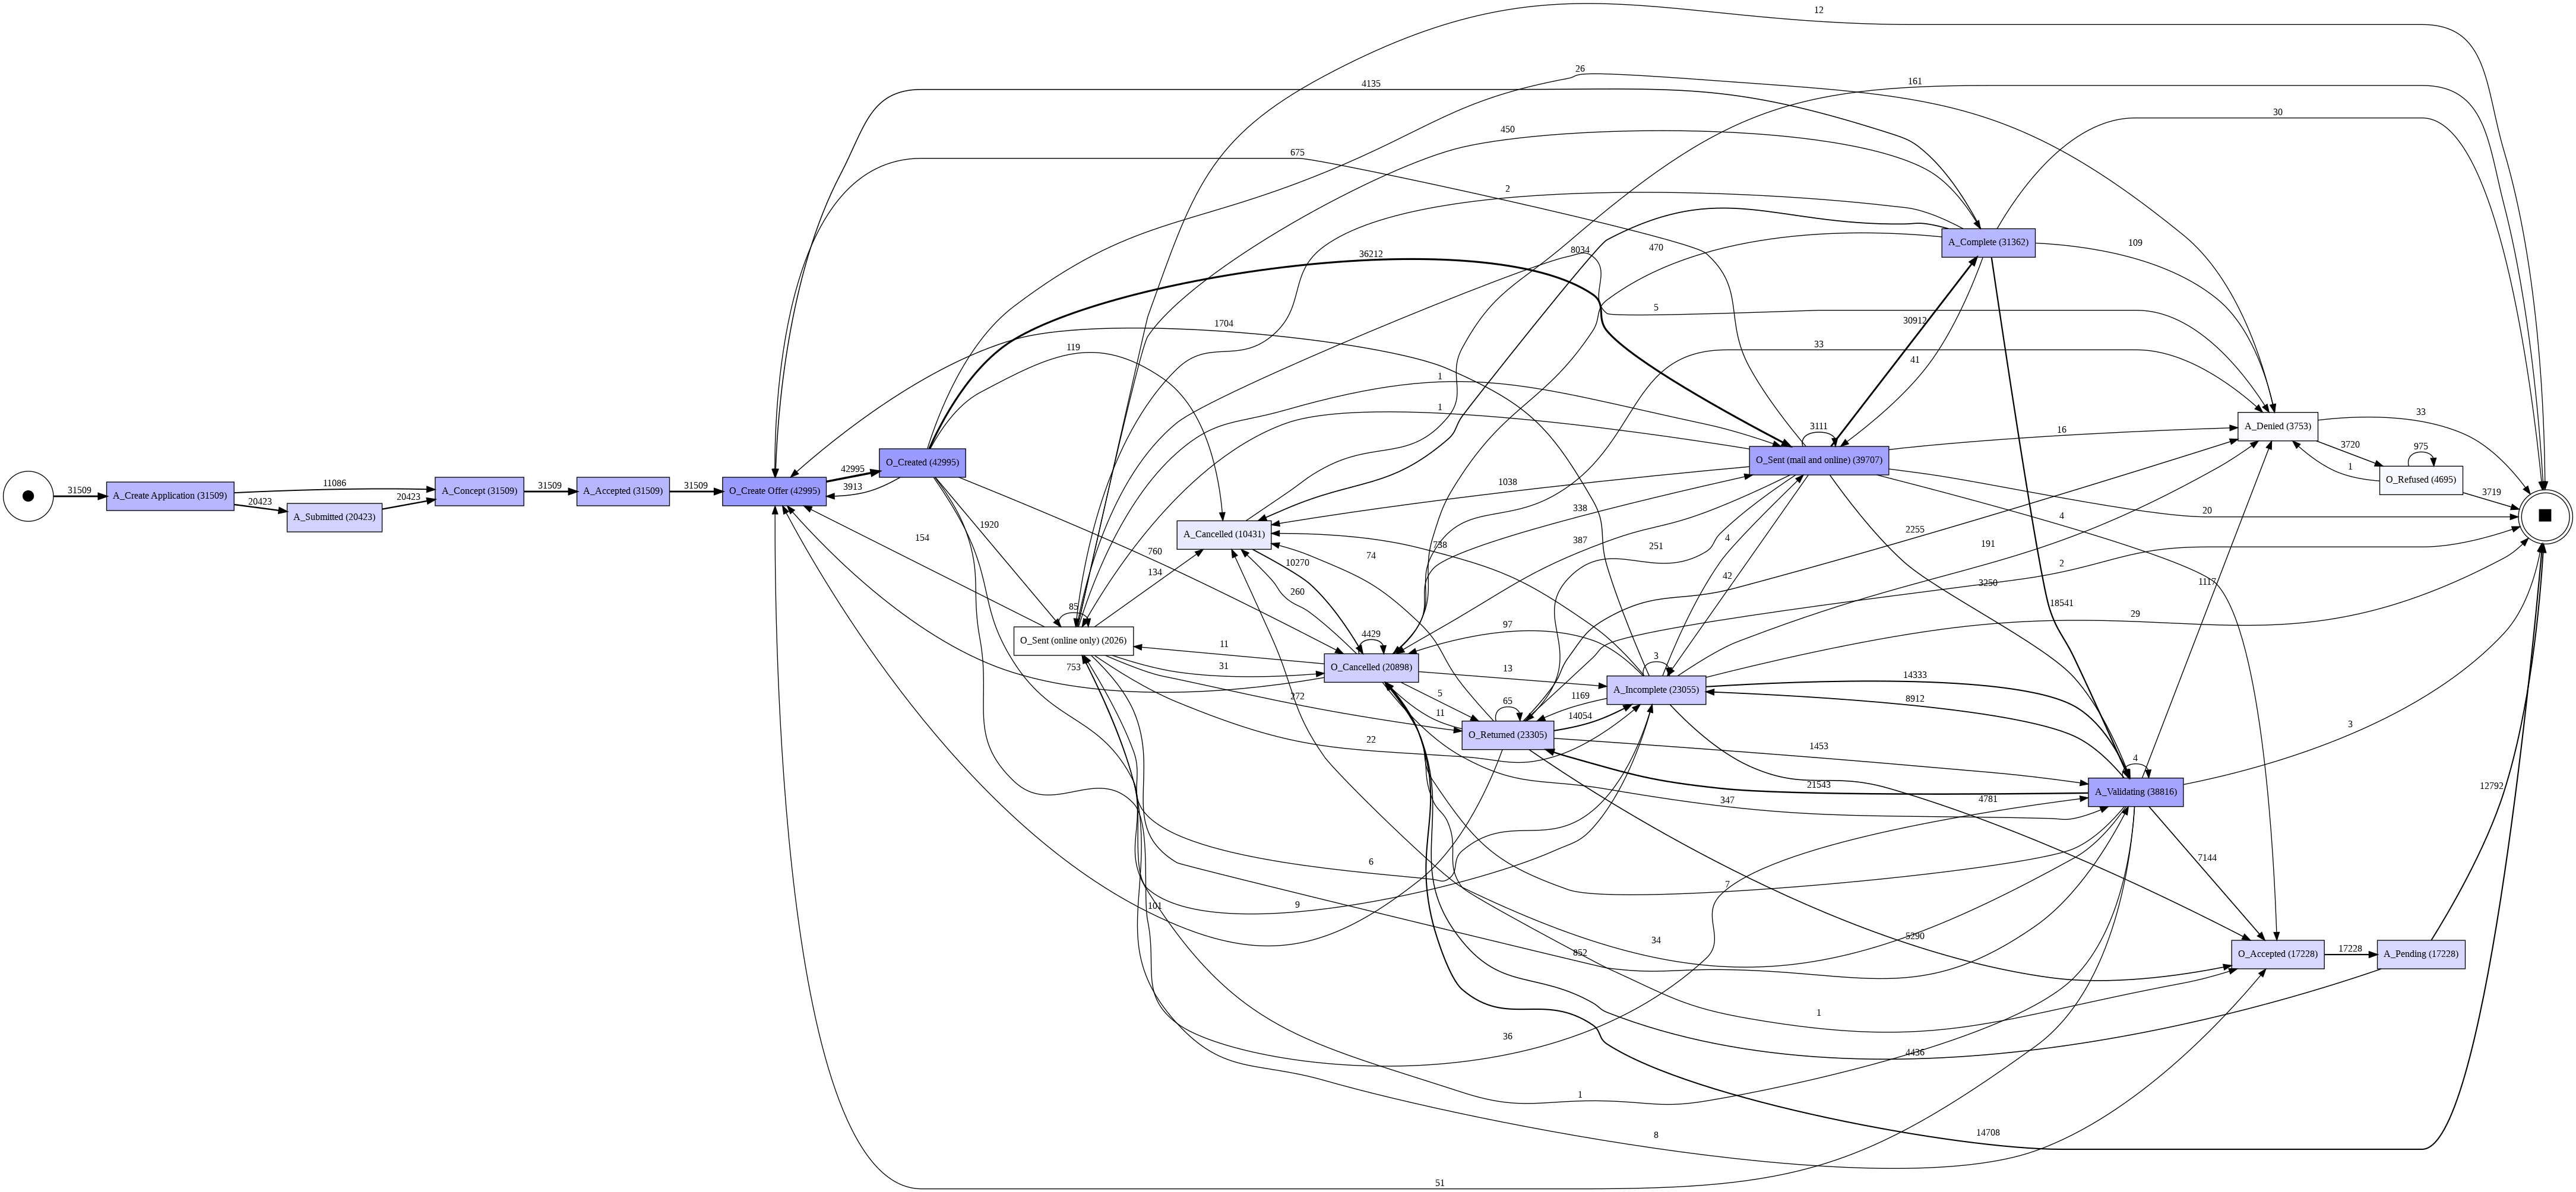

In [82]:
dfg, start_activities, end_activities_ao = pm4py.discover_dfg(log_ao)
pm4py.view_dfg(dfg, start_activities, end_activities_ao)

#### Alpha miner - net (petri net)

##### Full log

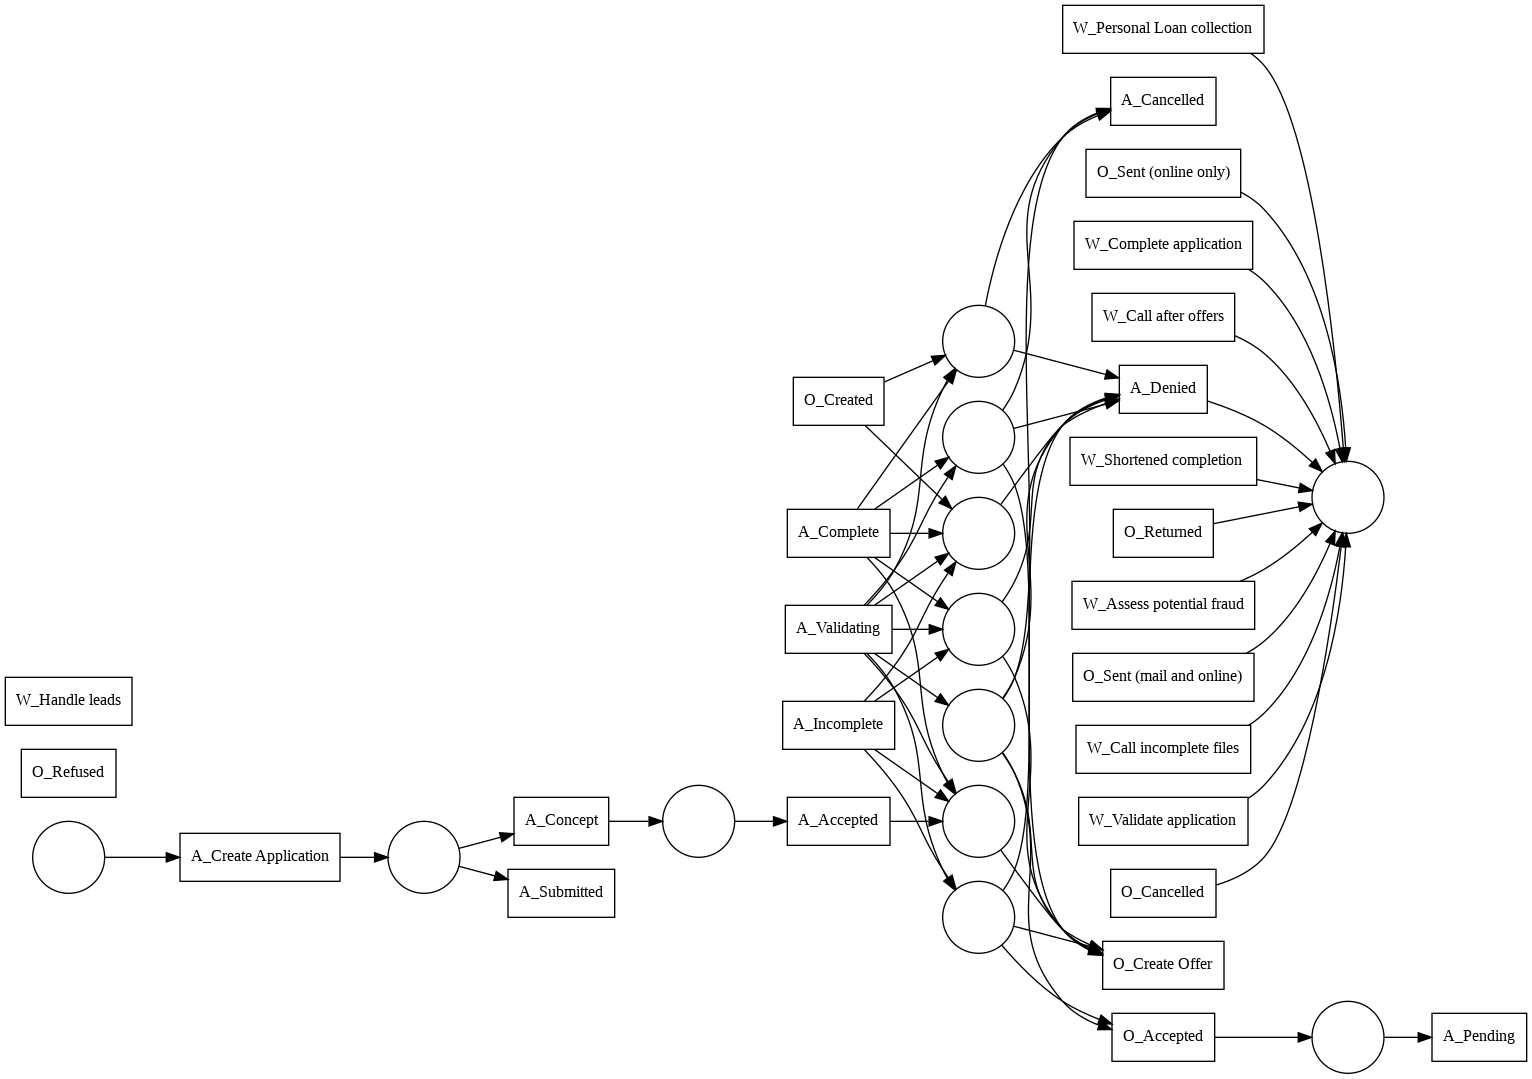

In [89]:
net, initial_marking, final_marking = pm4py.discover_petri_net_alpha(log)
pm4py.view_petri_net(net)

##### Filtered log A_, and O_

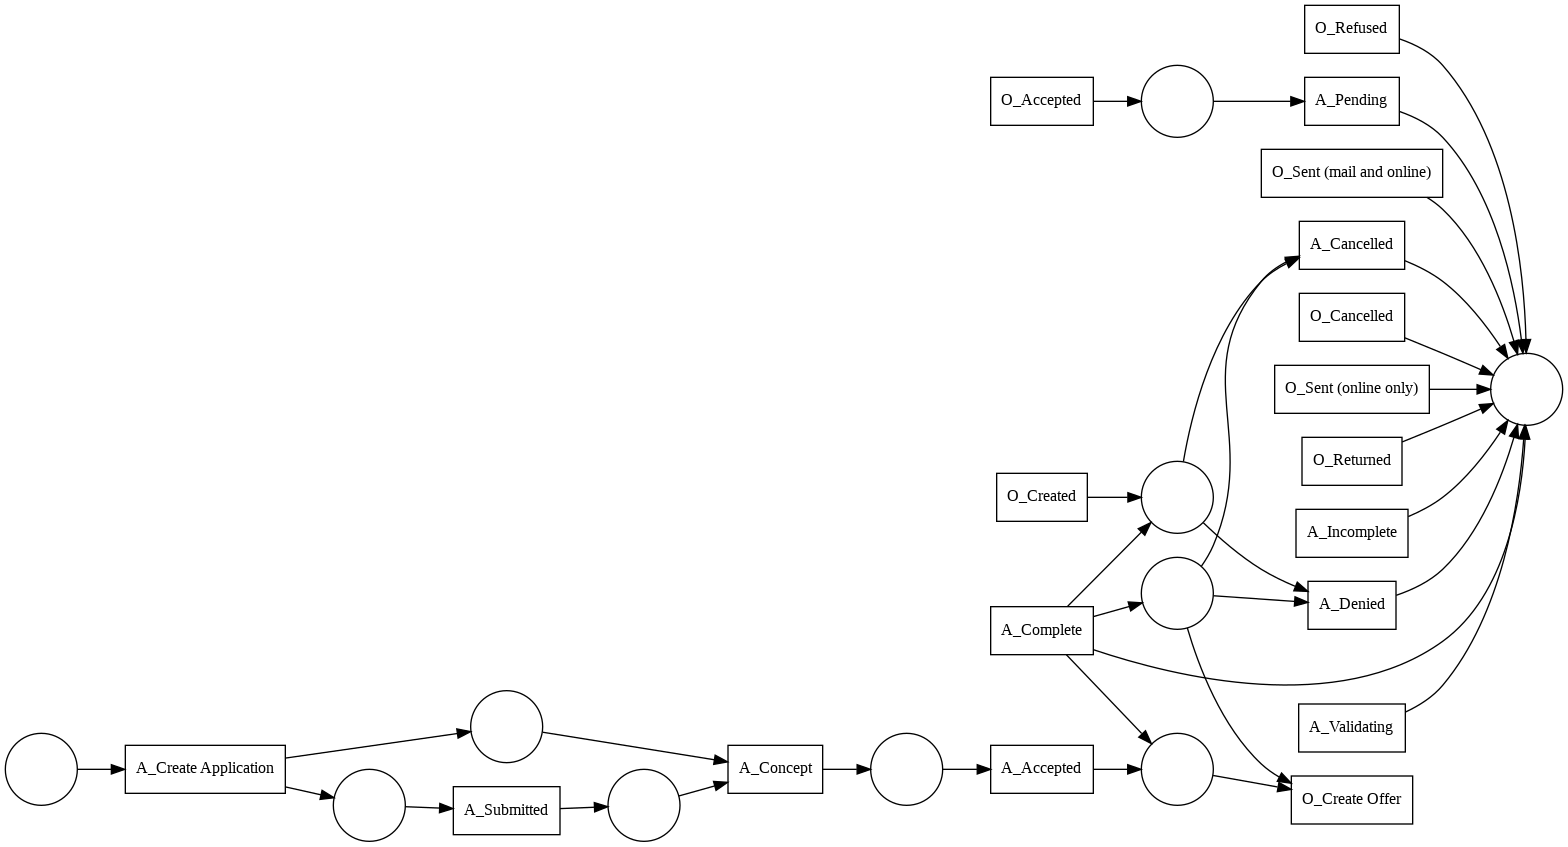

In [69]:
net, initial_marking, final_marking = pm4py.discover_petri_net_alpha(log_ao)
pm4py.view_petri_net(net)

#### Inductive miner

##### Filtered Log A_, and O_

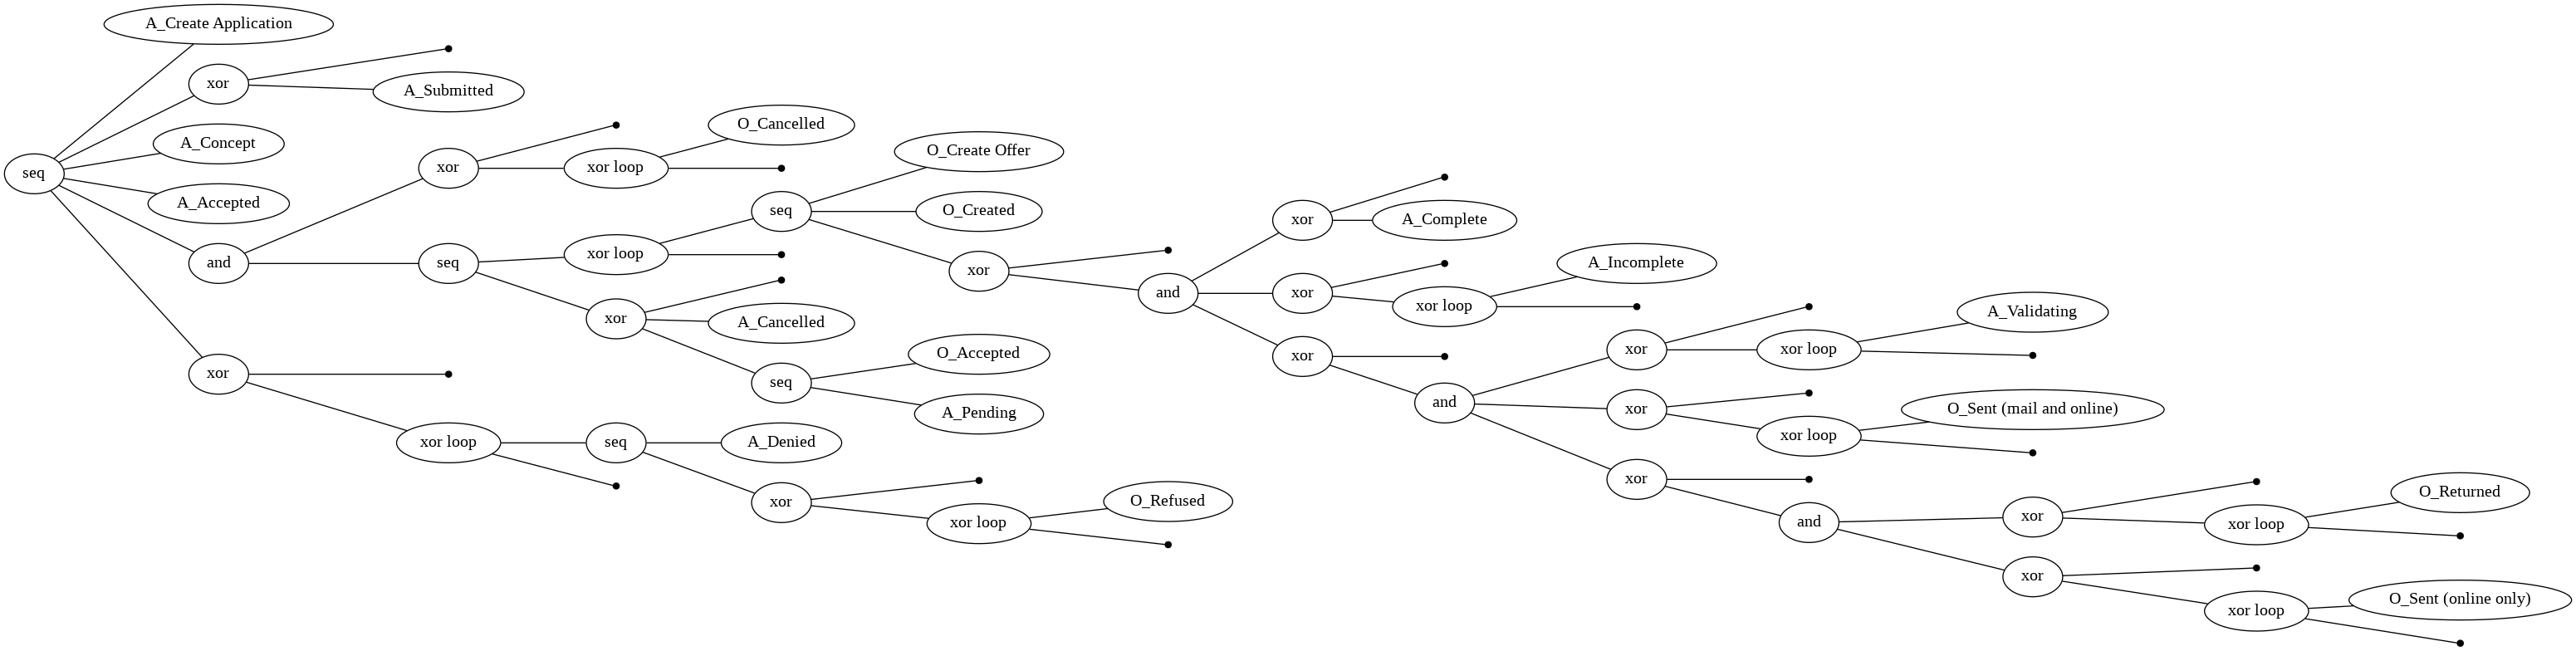

In [70]:
net, initial_marking, final_marking = pm4py.discover_petri_net_inductive(log_ao)
tree = pm4py.discover_process_tree_inductive(log_ao)
pm4py.view_process_tree(tree)

##### Full Log

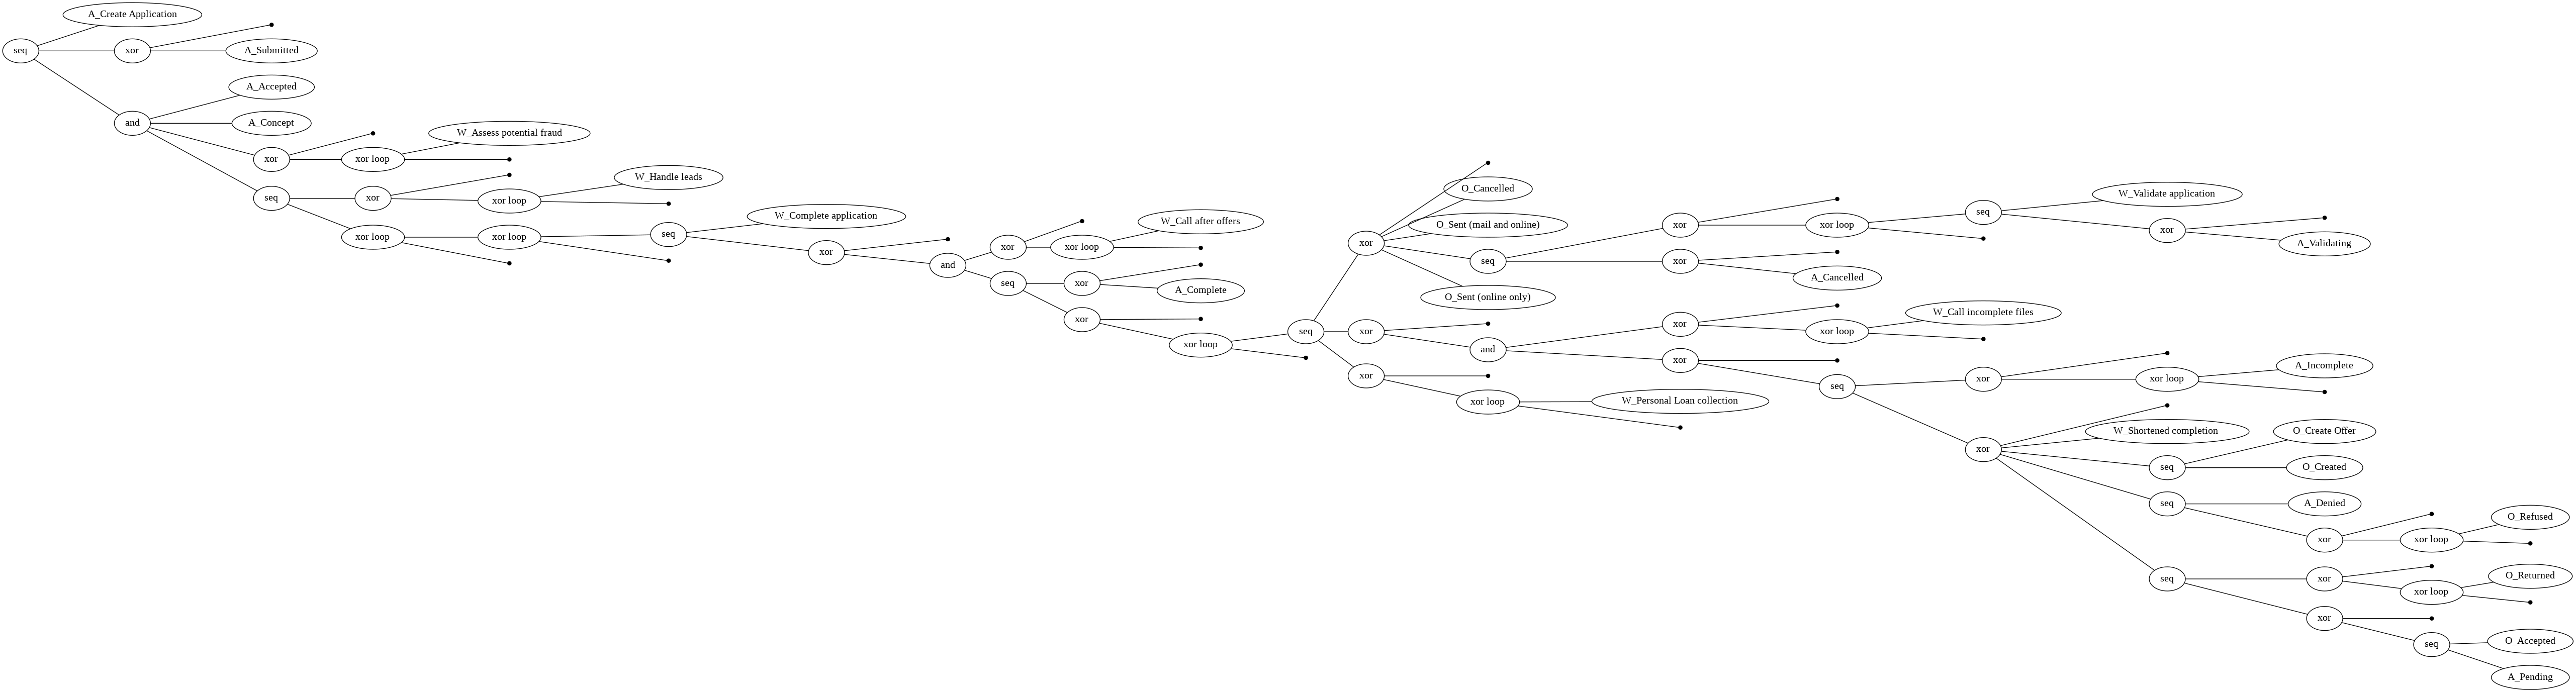

In [90]:
net, initial_marking, final_marking = pm4py.discover_petri_net_inductive(log)
tree = pm4py.discover_process_tree_inductive(log)
pm4py.view_process_tree(tree)

#### Heuristic miner

##### filtered log A_ and O_

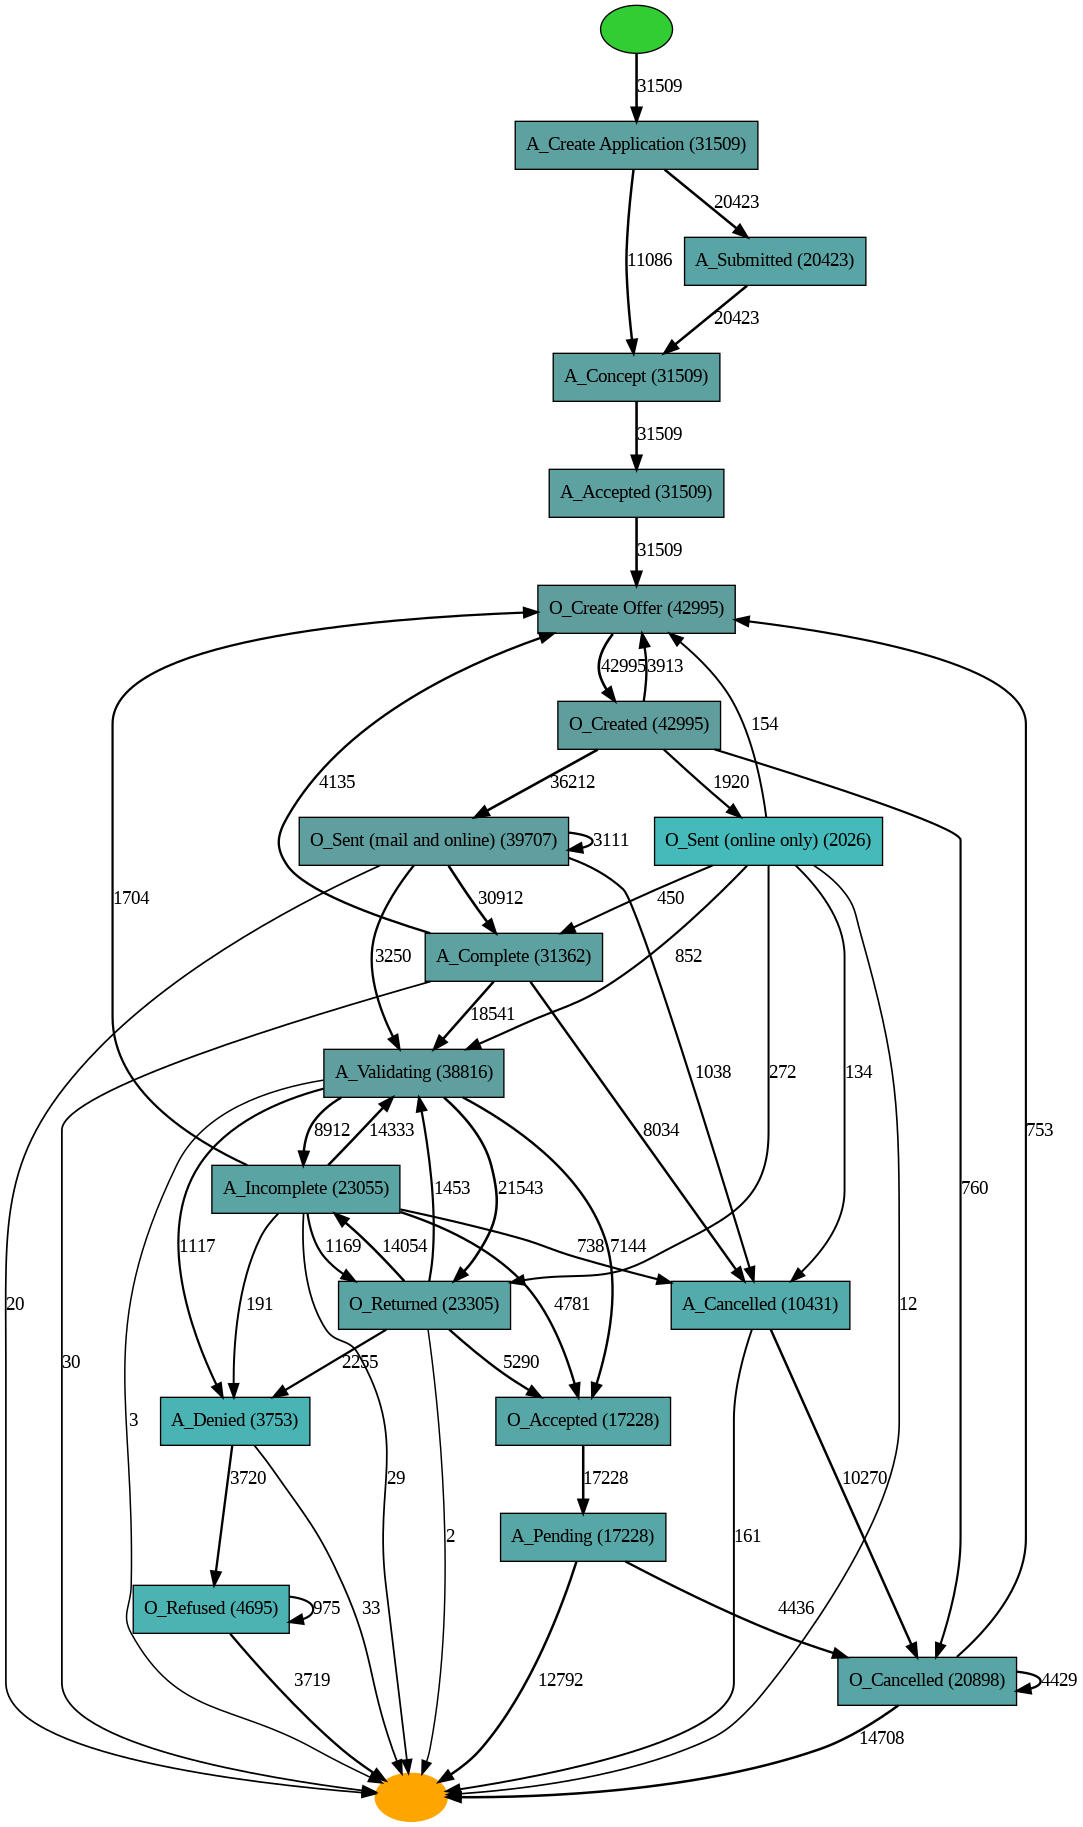

In [71]:
heu_net = pm4py.discover_heuristics_net(log_ao, dependency_threshold=0.90)
pm4py.view_heuristics_net(heu_net)

##### Full log

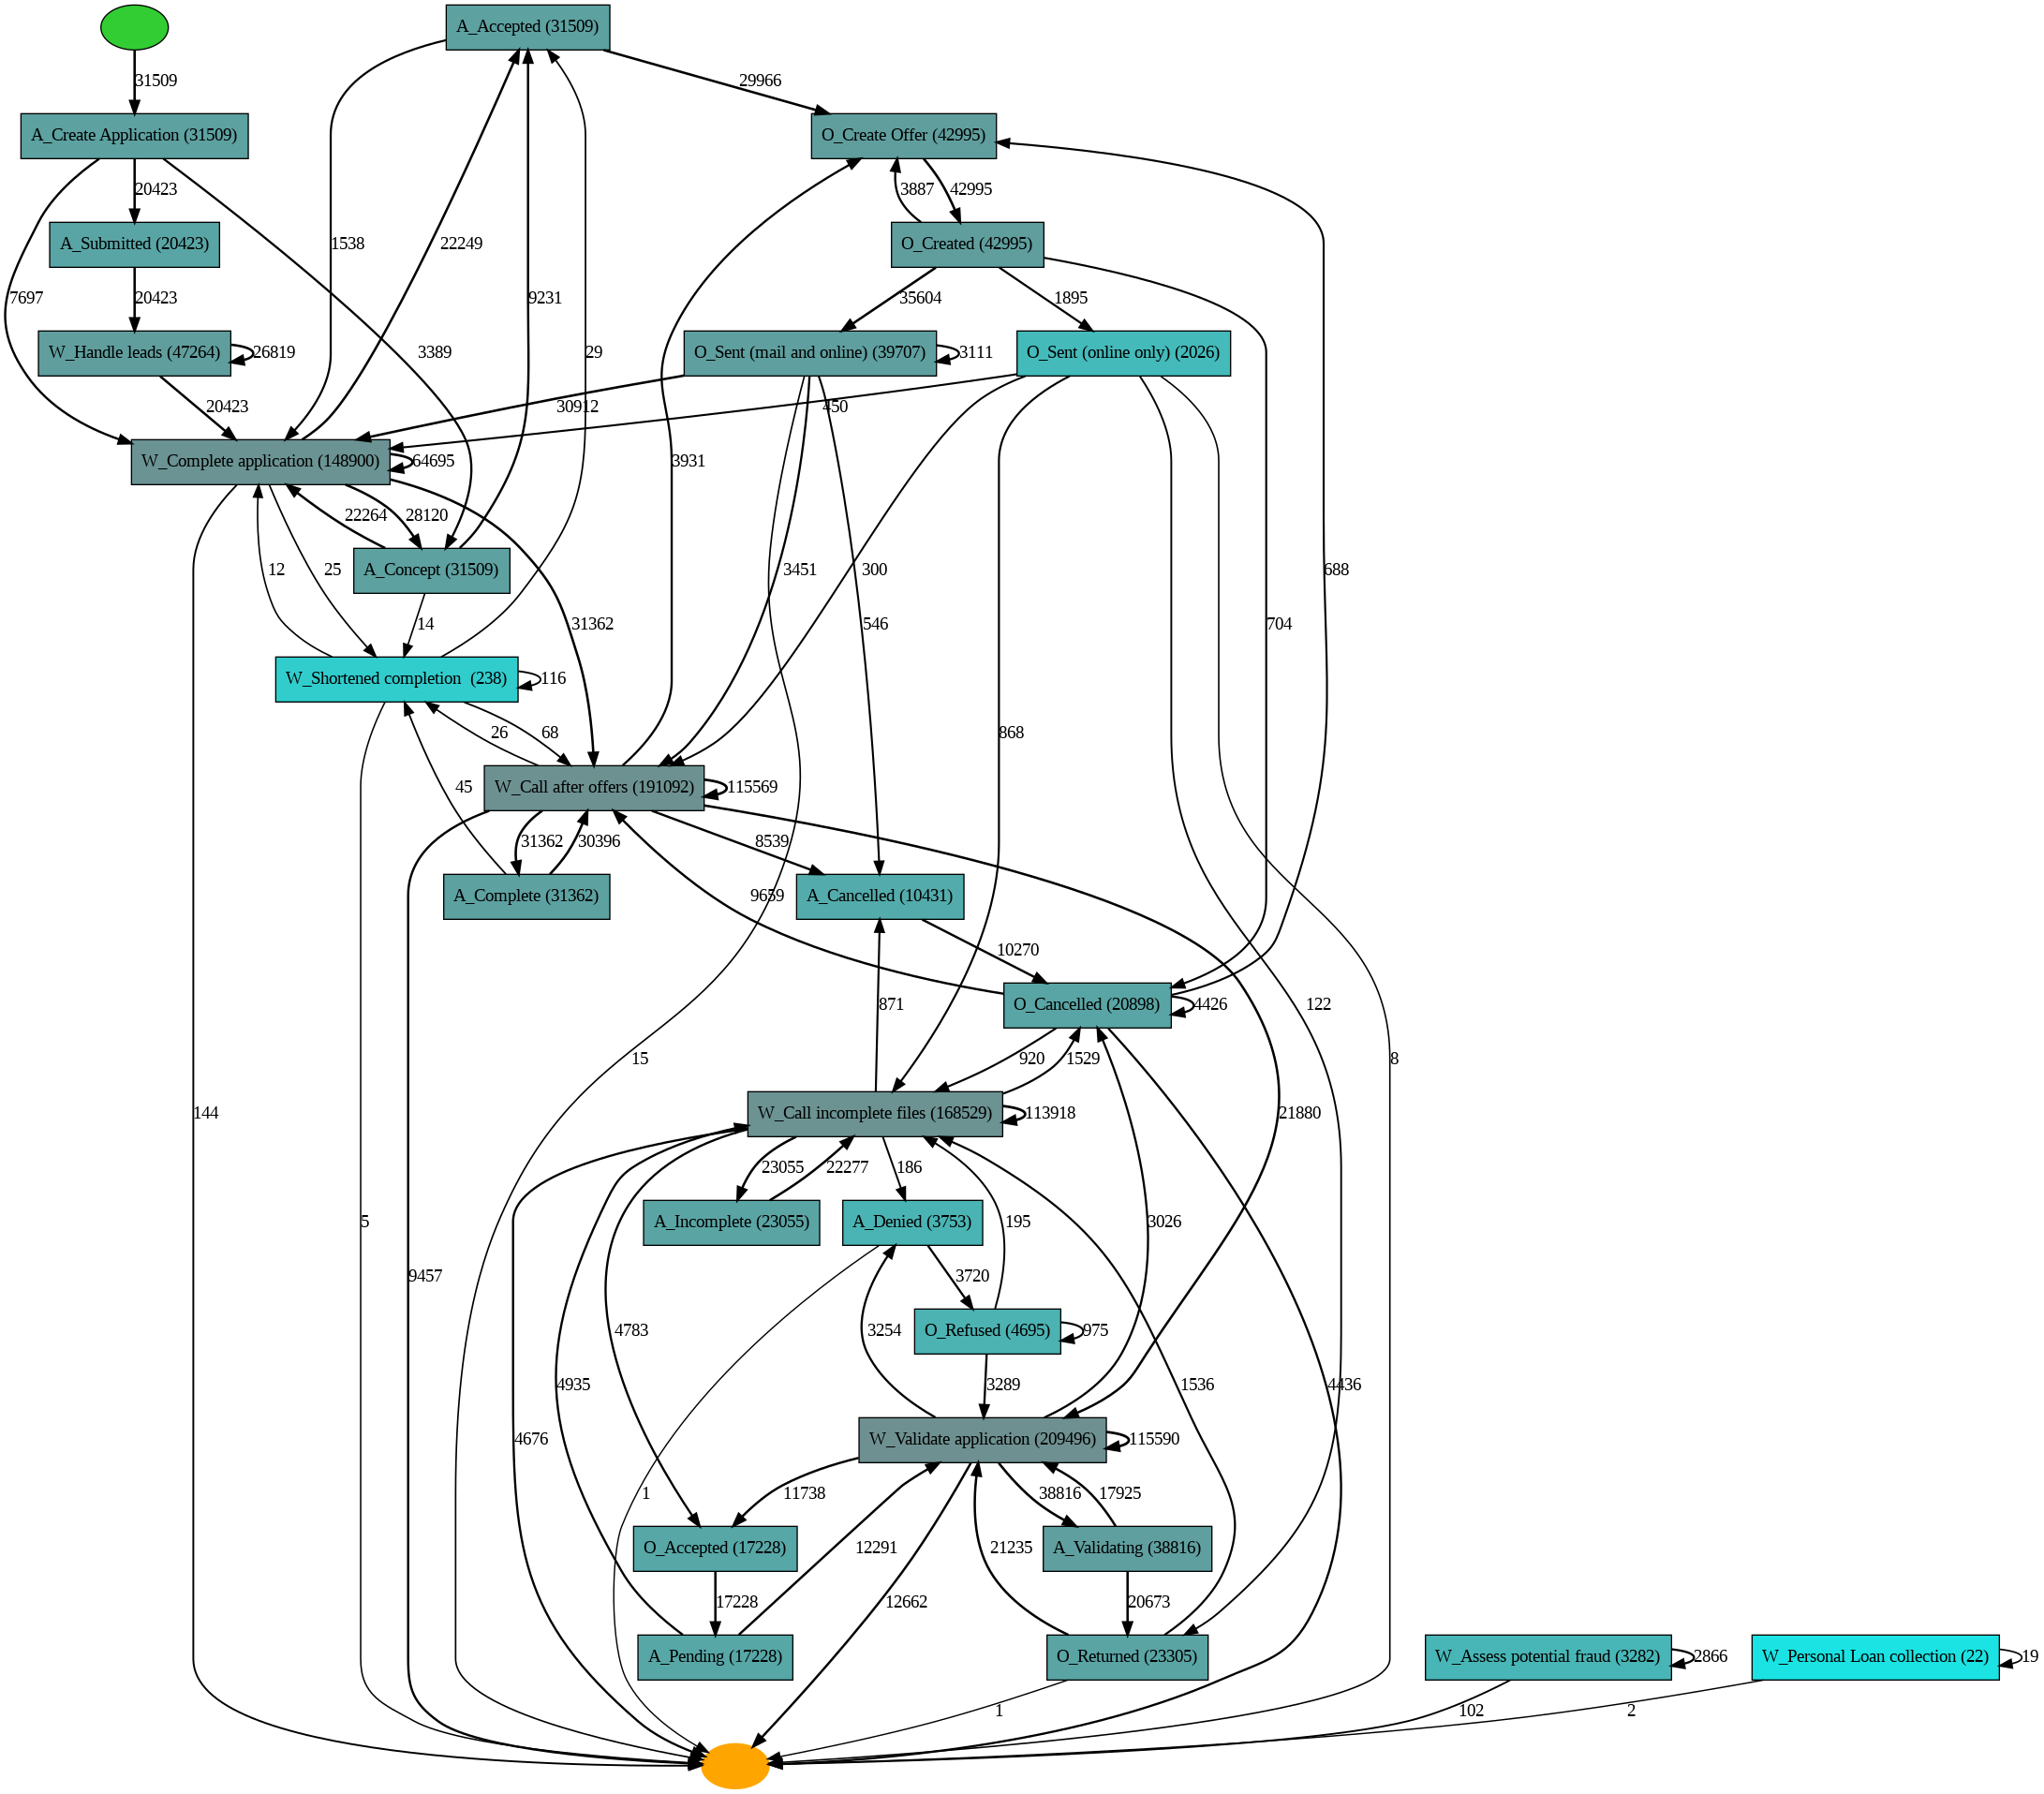

In [92]:
heu_net = pm4py.discover_heuristics_net(log, dependency_threshold=0.90)
pm4py.view_heuristics_net(heu_net)